In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [28]:
from data_science.plots import plot_clusters, plot_dendrogram, plot_pca_scatter


## Data


In [29]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [30]:
data = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names,
)

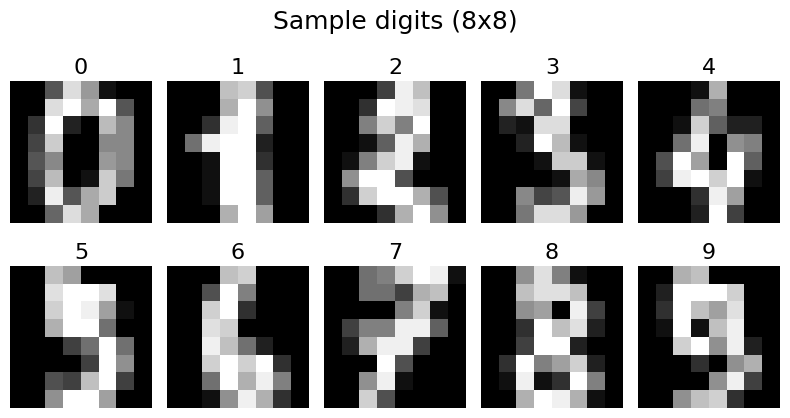

In [31]:
images = dataset.images
fig, axes = plt.subplots(2, 5, figsize=(8, 4.5))
plt.gray()
for ax, img, label in zip(axes.ravel(), images[:10], dataset.target[:10], strict=True):
    ax.imshow(img)
    ax.set_title(f'{label}', fontsize=16)
    ax.axis('off')
plt.suptitle('Sample digits (8x8)', fontsize=18)
plt.tight_layout()
plt.show()

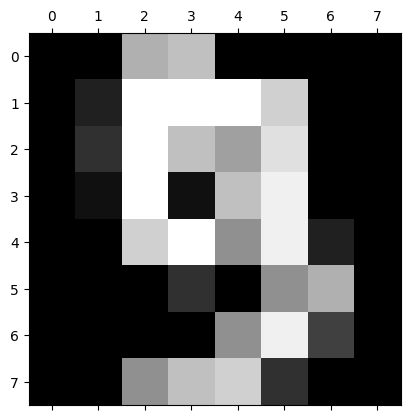

In [32]:
plt.matshow(dataset.data[9].reshape(8, 8))

## Prepare Data


In [33]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x117E1E340

In [34]:
X = data
y = dataset.target

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## PCA


In [37]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_2d.fit_transform(X_scaled)

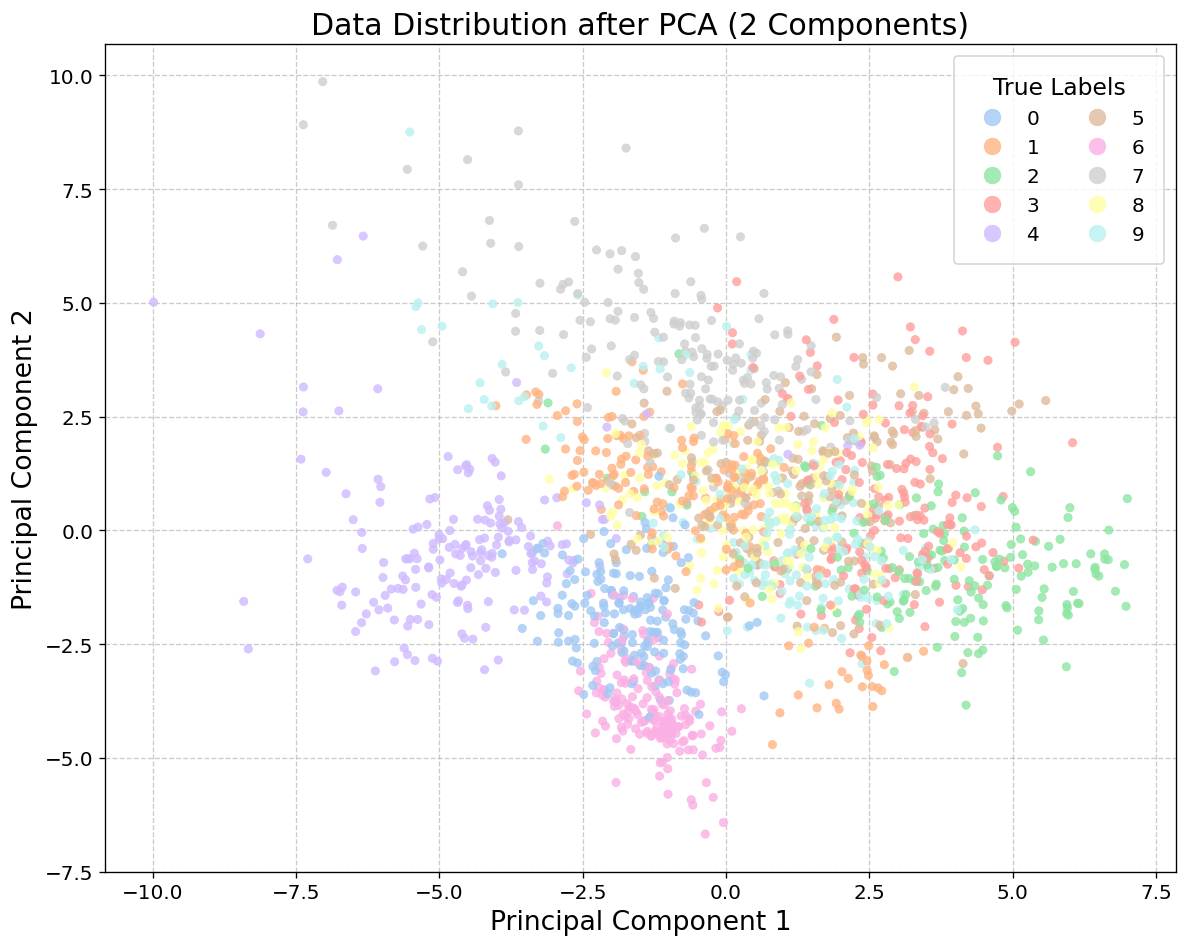

In [38]:
plot_pca_scatter(
    X_pca_2d, y, title='Data Distribution after PCA (2 Components)', palette=sns.color_palette('pastel', 10)
)

## Agglomerative Clustering

### Ward Linkage


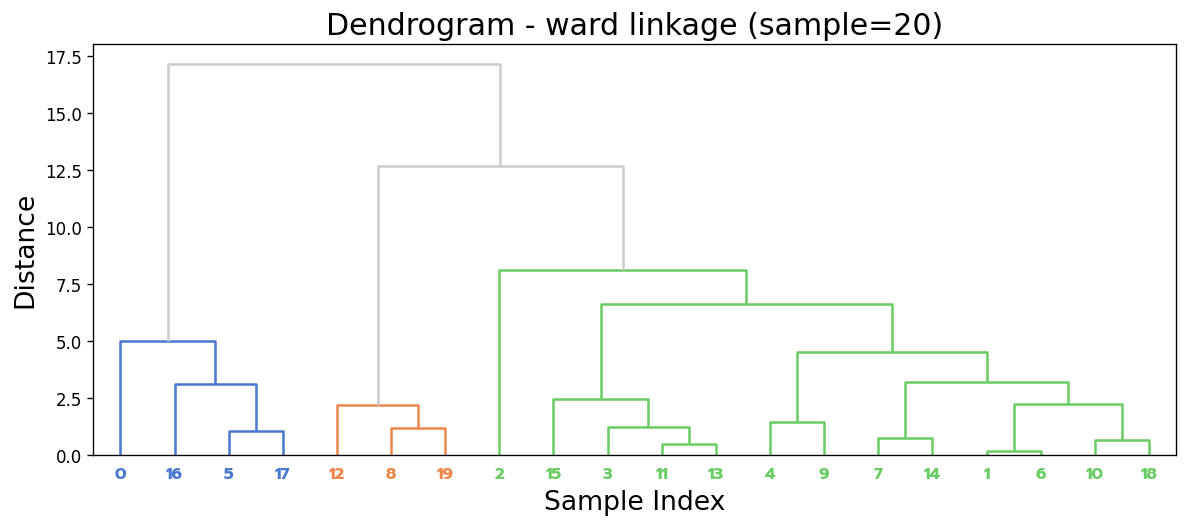

In [39]:
plot_dendrogram(X_pca_2d, p=2, method="ward", size=20)

In [40]:
agg_ward = AgglomerativeClustering(
    n_clusters=10,
    metric="euclidean",
    linkage="ward",
)
agg_ward.fit(X_pca_2d)

,n_clusters,10
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


(1797,)
(1797, 2)


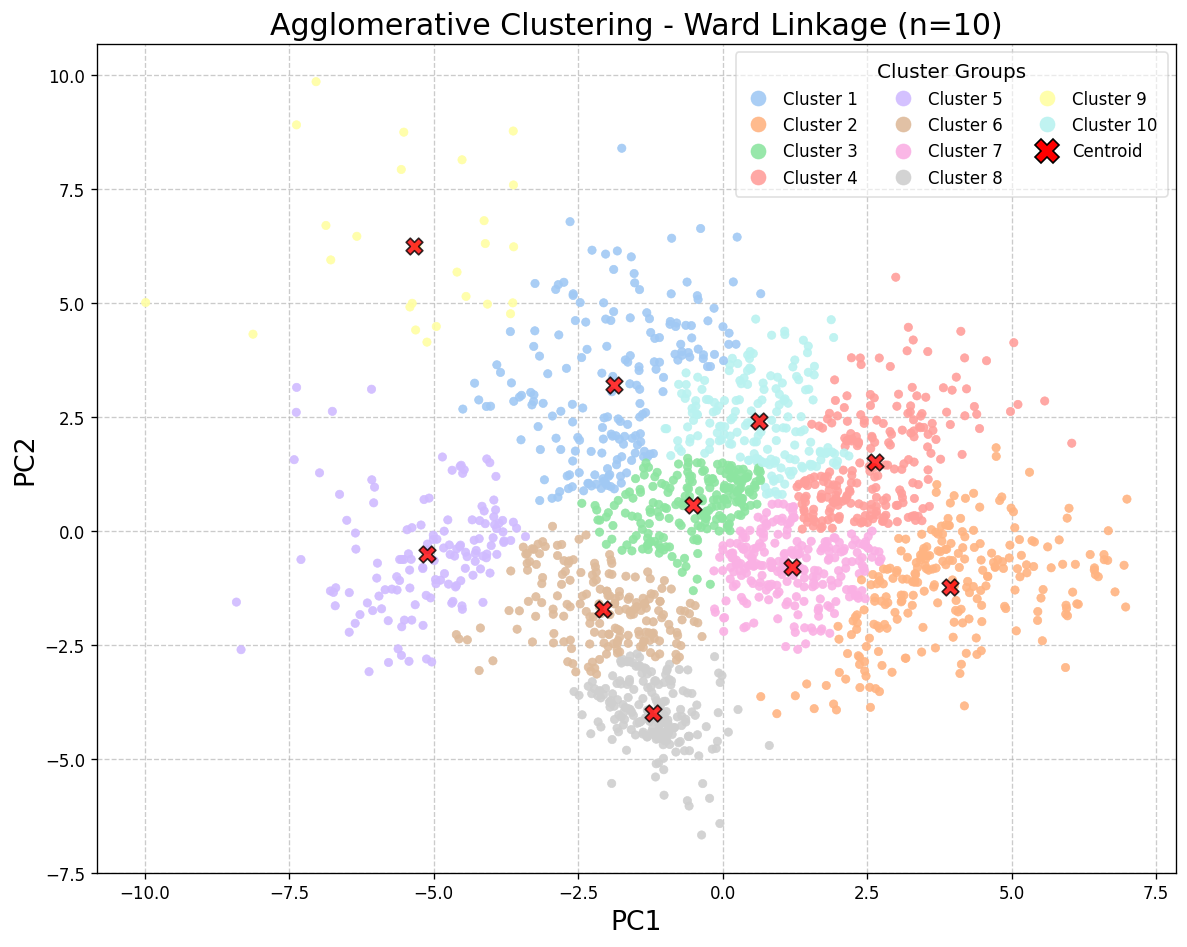

In [41]:
print(agg_ward.labels_.shape)
print(X_pca_2d.shape)
plot_clusters(
    agg_ward.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Ward Linkage (n=10)',
    palette='pastel',
)

### Complete Linkage


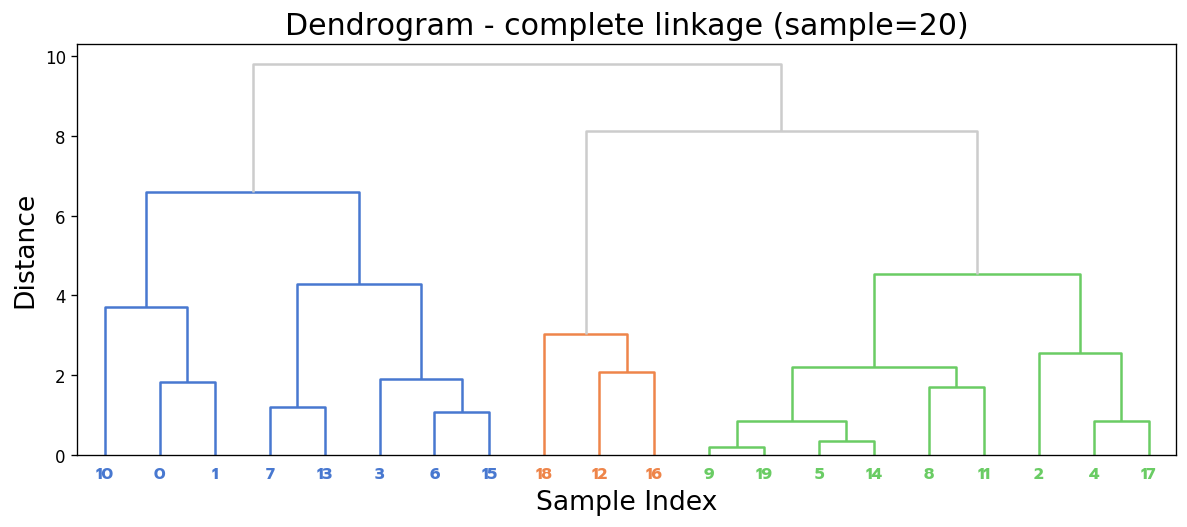

In [42]:
plot_dendrogram(X_pca_2d, p=2, method="complete", size=20)

In [43]:
agg_complete = AgglomerativeClustering(
    n_clusters=10,
    metric="euclidean",
    linkage="complete",
)
agg_complete.fit(X_pca_2d)

,n_clusters,10
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,None
,compute_distances,False


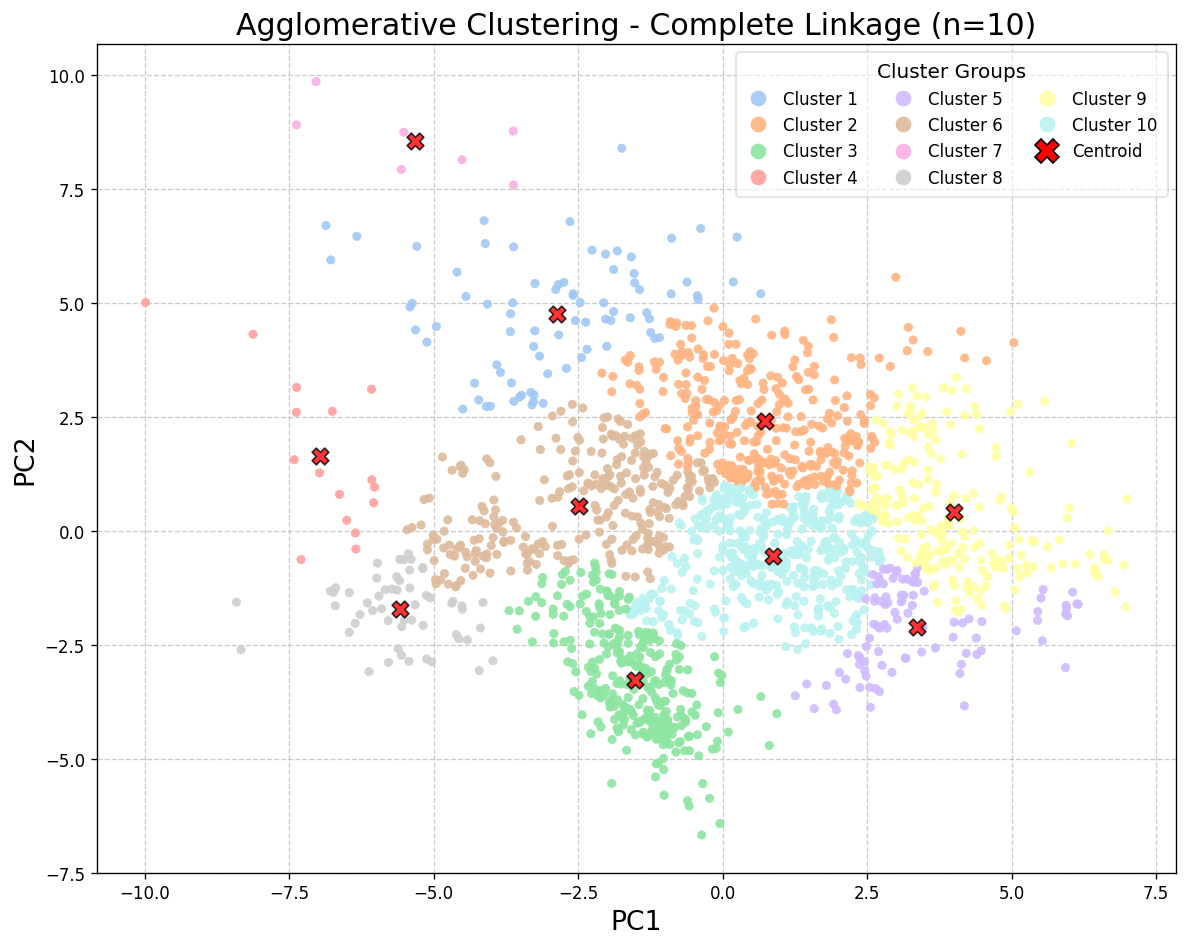

In [44]:
plot_clusters(
    agg_complete.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Complete Linkage (n=10)',
    palette='pastel',
)

### Average Linkage


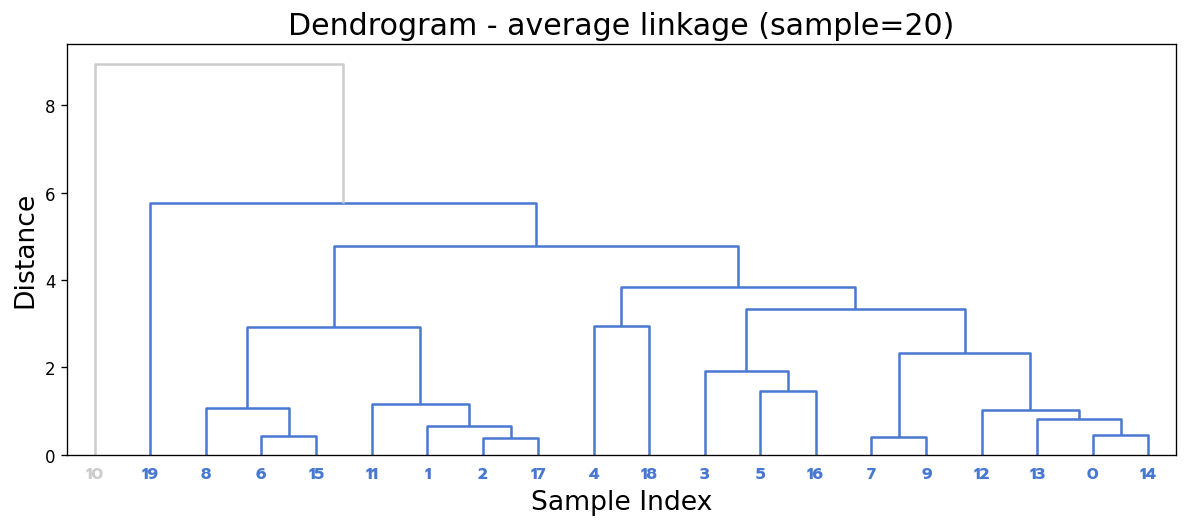

In [45]:
plot_dendrogram(X_pca_2d, p=10, method="average", size=20)

In [46]:
agg_average = AgglomerativeClustering(
    n_clusters=10,
    metric="euclidean",
    linkage="average",
)
agg_average.fit(X_pca_2d)

,n_clusters,10
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'average'
,distance_threshold,None
,compute_distances,False


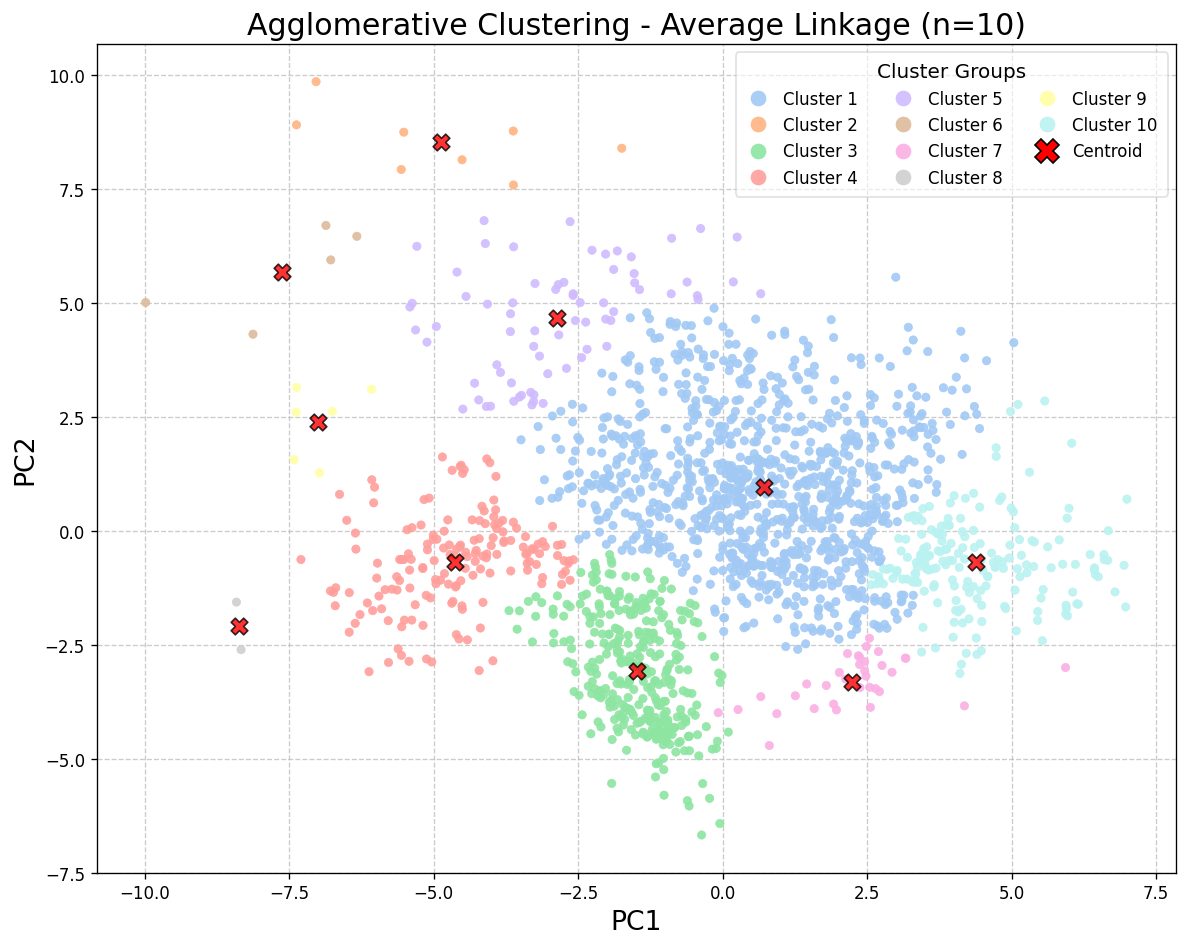

In [47]:
plot_clusters(
    agg_average.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Average Linkage (n=10)',
    palette='pastel',
)

### Single Linkage


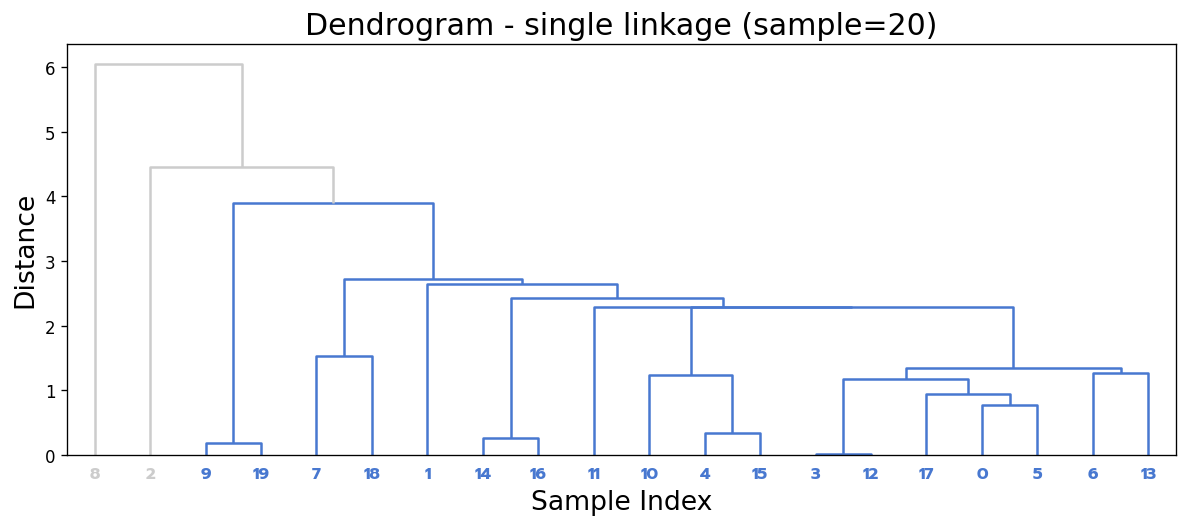

In [48]:
plot_dendrogram(X_pca_2d, p=10, method="single", size=20)

In [49]:
agg_single = AgglomerativeClustering(
    n_clusters=10,
    metric="euclidean",
    linkage="single",
)
agg_single.fit(X_pca_2d)

,n_clusters,10
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'single'
,distance_threshold,None
,compute_distances,False


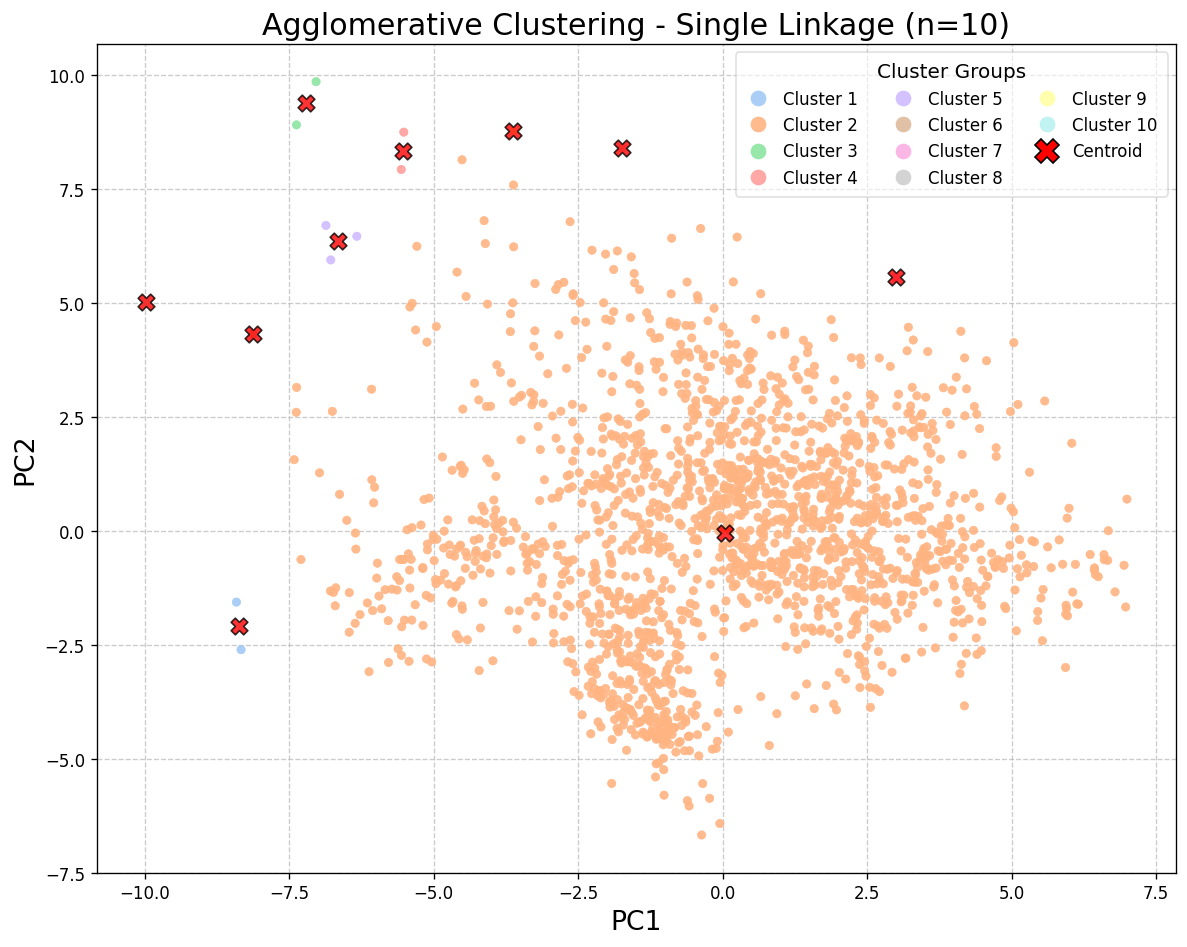

In [50]:
plot_clusters(
    agg_single.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Single Linkage (n=10)',
    palette='pastel',
)

In [ ]:
# TODO: metrics comparison